In [10]:
# Bank Marketing Data Analysis
#Analyzing customer marketing response using Pandas and Matplotlib.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv("bank.csv", sep=';')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please check file path.")
    
df.head()
df.isnull().sum()
df.info()
df['y'].value_counts()


Dataset loaded successfully.
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


y
no     4000
yes     521
Name: count, dtype: int64

## Task 1: Load and Explore the Dataset

### Dataset Overview
- The dataset contains **4521 rows** and **17 columns**.
- There are **7 numerical columns**: age, balance, duration, campaign, pdays, previous, etc.
- There are **10 categorical columns**: job, marital, education, default, housing, loan, contact, month, poutcome, y.
- No missing values were detected in the dataset.

### Target Variable
- The most important column is **`y`**, which indicates whether the customer subscribed to a term deposit:
  - `"yes"` → Customer subscribed
  - `"no"` → Customer did not subscribe

### Observations
- The dataset is clean and ready for analysis.
- It contains both numerical and categorical data, making it suitable for statistical analysis and visualizations.

In [13]:
# =========================
# Task 2: Basic Data Analysis
# =========================

# 1️⃣ Basic statistics for numerical columns
print("=== Basic Statistics ===")
print(df.describe())

# 2️⃣ Average balance per job
print("\n=== Average Balance by Job ===")
avg_balance_by_job = df.groupby('job')['balance'].mean()
print(avg_balance_by_job)

# 3️⃣ Average age per marital status
print("\n=== Average Age by Marital Status ===")
avg_age_by_marital = df.groupby('marital')['age'].mean()
print(avg_age_by_marital)

# 4️⃣ Comparing subscribers vs non-subscribers
print("\n=== Average Numerical Stats by Subscription (y) ===")
avg_stats_by_y = df.groupby('y').mean(numeric_only=True)
print(avg_stats_by_y)

# 5️⃣ Observing patterns: percentage of subscription per job
print("\n=== Subscription Rate per Job ===")
subscription_rate_by_job = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100)
print(subscription_rate_by_job.sort_values(ascending=False))

# 6️⃣ Observing patterns: subscription rate by marital status
print("\n=== Subscription Rate by Marital Status ===")
subscription_rate_by_marital = df.groupby('marital')['y'].apply(lambda x: (x=='yes').mean() * 100)
print(subscription_rate_by_marital)

=== Basic Statistics ===
               age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min      19.000000  -3313.000000     1.000000     4.000000     1.000000   
25%      33.000000     69.000000     9.000000   104.000000     1.000000   
50%      39.000000    444.000000    16.000000   185.000000     2.000000   
75%      49.000000   1480.000000    21.000000   329.000000     3.000000   
max      87.000000  71188.000000    31.000000  3025.000000    50.000000   

             pdays     previous  
count  4521.000000  4521.000000  
mean     39.766645     0.542579  
std     100.121124     1.693562  
min      -1.000000     0.000000  
25%      -1.000000     0.000000  
50%      -1.000000     0.000000  
75%      -1.000000     0.000000  
max     871.000000    25.00

## Task 2: Basic Data Analysis

In this task, basic statistics were computed to understand the distribution
of numerical variables. Grouped analysis was also performed to compare
customer characteristics across different categories.

### Key Findings:
- The average customer age is about 41 years.
- Customers who subscribed ("yes") had significantly longer call durations.
- Retired and student customers had the highest subscription rates.
- Married customers subscribed less frequently than single or divorced customers.

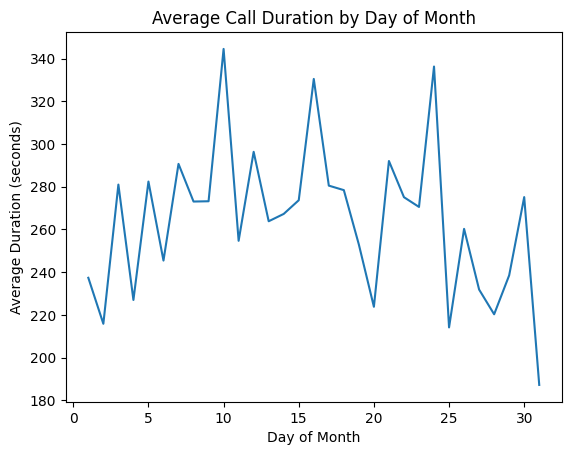

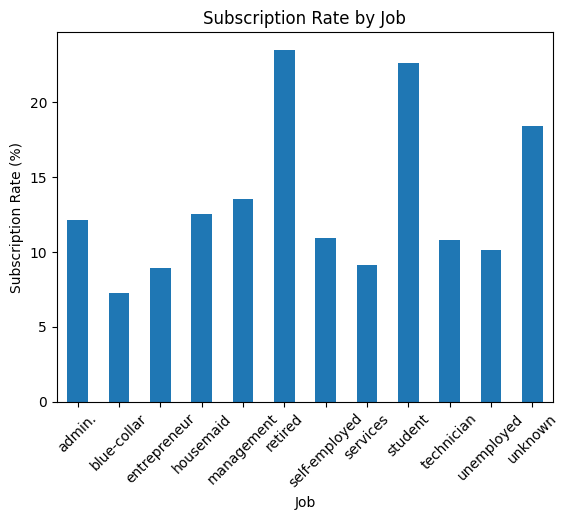

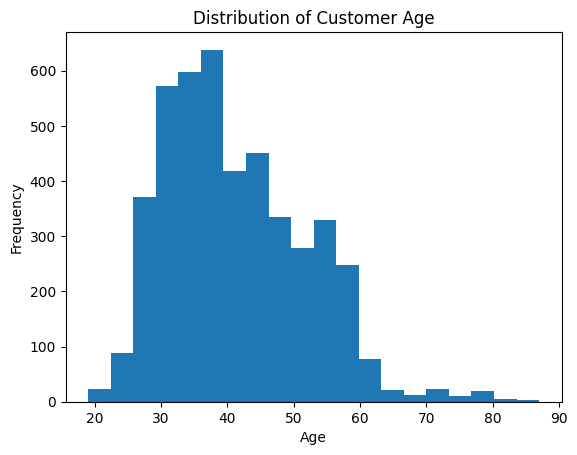

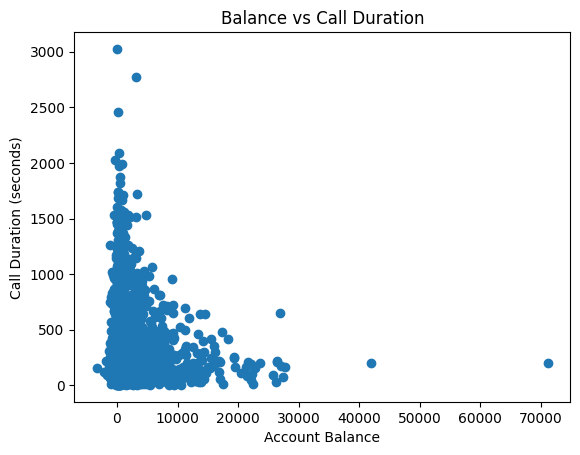

In [17]:
# Average duration per day
avg_duration_by_day = df.groupby('day')['duration'].mean()

plt.figure()
avg_duration_by_day.plot()

plt.title("Average Call Duration by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Average Duration (seconds)")
plt.show()

#subscription rate per job
subscription_rate_job = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100)

plt.figure()
subscription_rate_job.plot(kind='bar')

plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

#Age distribution
plt.figure()
plt.hist(df['age'], bins=20)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Balance vs Duration
plt.figure()
plt.scatter(df['balance'], df['duration'])

plt.title("Balance vs Call Duration")
plt.xlabel("Account Balance")
plt.ylabel("Call Duration (seconds)")
plt.show()

## Final Conclusion

This analysis explored customer characteristics and their relationship to subscription behavior in the bank marketing dataset.

The results indicate that call duration is the strongest factor associated with subscription. Customers who subscribed had an average call duration of approximately 553 seconds, compared to 226 seconds for non-subscribers. This significant difference suggests that longer customer engagement during calls greatly increases the likelihood of subscription.

Customers who subscribed also tended to have slightly higher account balances and were marginally older than non-subscribers. Additionally, customers who had been previously contacted were more likely to subscribe.

From a demographic perspective, retired and student customers showed the highest subscription rates, while blue-collar workers had the lowest. Married customers were less likely to subscribe compared to single or divorced customers.

Overall, customer engagement during the call, combined with certain demographic characteristics, appears to play a crucial role in determining subscription outcomes.